# Using k-order Dynamic Bayesian Networks (k-TBN)

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F75-PyModels_KTBN.ipynb)

A **k-TBN** (k-order dynamic Bayesian network) generalizes the classical 2-TBN: instead of letting a variable at time $t$ depend on a single step backward, it lets it depend on up to the $k$ most recent time slices. A k-TBN is a *template* of $k$ consecutive slices; unrolling it for any horizon $T \geq k$ produces a plain `pyagrum.BayesNet`.

A k-TBN distinguishes two kinds of variables:
- **temporal** variables (processes), which evolve through time and have one instance per slice,
- **atemporal** variables, constant through time (e.g. a static context), which have a single instance.

(For more details see https://pyagrum.readthedocs.io/en/latest/ktbn.html)

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.ktbn as ktbn

## Building a k-TBN by hand

A small weather example: whether it `Rain`s and whether an `Umbrella` is carried depend on the previous time slice, and both depend on the (atemporal) `Season`. `Rain` and `Umbrella` are added as *temporal* processes (one instance per slice); `Season` is added as *atemporal* (a single instance, addressed with `ktbn.KTBN.ATEMPORAL`).

In [2]:
m = ktbn.KTBN(2)  # k=2: each variable depends on at most the previous slice

m.addTemporal(gum.LabelizedVariable("Rain", "raining?", ["no", "yes"]))
m.addTemporal(gum.LabelizedVariable("Umbrella", "umbrella carried?", ["no", "yes"]))
m.addAtemporal(gum.LabelizedVariable("Season", "season", ["dry", "wet"]))

m.addArc("Season", ktbn.KTBN.ATEMPORAL, "Rain", 0)
m.addArc("Season", ktbn.KTBN.ATEMPORAL, "Rain", 1)
m.addArc("Rain", 0, "Rain", 1)
m.addArc("Rain", 0, "Umbrella", 0)
m.addArc("Rain", 1, "Umbrella", 1)

print(m)

<pyagrum.ktbn.ktbncpp.KTBN; proxy of <Swig Object of type 'gum::KTBN< double > *' at 0x10b259630> >


Nodes can be addressed either by an explicit `(base, slice)` pair, or by their *engine name* using bracket notation (`"Rain[1]"` for `Rain` at slice 1, a bare name like `"Season"` for an atemporal variable). Both spellings are accepted almost everywhere, including `toDot()`'s slice-clustered rendering below.

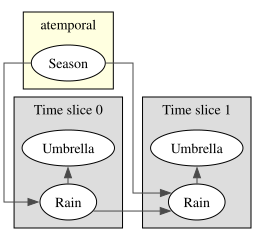

In [3]:
gnb.showDot(m.toDot())

`fillCPT` fills one conditional distribution at a time, addressing the node and its parents by name instead of by CPT positional order -- convenient once a k-TBN has more than a couple of parents per node. When the target node is given as `"base[slice]"`, parent keys can freely mix engine names and `(base, slice)` tuples; when the target is given as a `(base, slice)` pair instead, every parent key must also be a tuple.

In [4]:
m.fillCPT("Season", ktbn.KTBN.ATEMPORAL, {}, [0.5, 0.5])

m.fillCPT("Rain[0]", {"Season": "dry"}, [0.9, 0.1])
m.fillCPT("Rain[0]", {"Season": "wet"}, [0.4, 0.6])
m.fillCPT("Rain[1]", {"Rain[0]": "no", "Season": "dry"}, [0.8, 0.2])
m.fillCPT("Rain[1]", {"Rain[0]": "yes", "Season": "dry"}, [0.5, 0.5])
m.fillCPT("Rain[1]", {"Rain[0]": "no", "Season": "wet"}, [0.3, 0.7])
m.fillCPT("Rain[1]", {"Rain[0]": "yes", "Season": "wet"}, [0.1, 0.9])

m.fillCPT("Umbrella[0]", {"Rain[0]": "no"}, [0.9, 0.1])
m.fillCPT("Umbrella[0]", {"Rain[0]": "yes"}, [0.2, 0.8])
m.fillCPT("Umbrella[1]", {"Rain[1]": "no"}, [0.9, 0.1])
m.fillCPT("Umbrella[1]", {"Rain[1]": "yes"}, [0.2, 0.8])

The same fast-construction syntax as `pyagrum.fastBN` is available through `gum.fastVariable`, using bracket notation to declare a process's domain directly in its name (`"X[2]"`): `add()` clones it into `k` instances unless `temporal=False` is passed.

In [5]:
m2 = ktbn.KTBN(2)
m2.add(gum.fastVariable("X[2]"))  # temporal by default: X[0], X[1]
m2.add(gum.fastVariable("C"), False)  # atemporal
m2.addArc("X", 0, "X", 1)
m2.addArc("C", ktbn.KTBN.ATEMPORAL, "X", 0)
m2.generateCPTs()  # random CPTs, useful for quick experiments
print(m2)

<pyagrum.ktbn.ktbncpp.KTBN; proxy of <Swig Object of type 'gum::KTBN< double > *' at 0x10beeedf0> >


## Unrolling into a plain Bayesian network

`unroll(T)` expands the template into a standard `pyagrum.BayesNet` with exactly `T` time slices: slices `0..k-1` are copied verbatim, every later slice replicates the transition kernel (slice `k-1`). The result can be used with any of pyAgrum's usual BN inference engines.

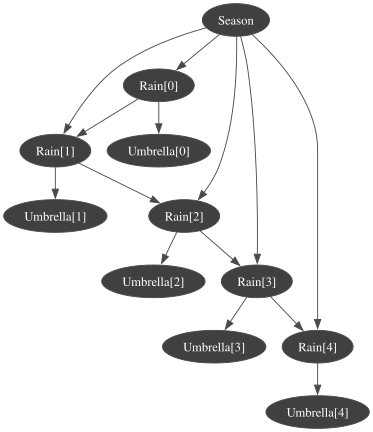

In [6]:
bn = m.unroll(5)
gnb.showBN(bn, size="6")

In [7]:
ie = gum.LazyPropagation(bn)
ie.makeInference()
ie.posterior("Rain[3]")

(pyagrum.Tensor@0x7b55a5e800) 
  Rain[3]          │
no       │yes      │
─────────│─────────│
 0.4233  │ 0.5767  │

## Inference directly on the k-TBN

`KTBNInference` runs inference over the k-TBN template directly, without materializing the unrolled network. It supports hard/soft observations, `do`-interventions, and both are addressed the same way as everywhere else: `(base, slice)` or an engine name.

In [8]:
kie = ktbn.KTBNInference(m)
kie.addObservation("Season", "wet")
kie.addObservation("Rain", 0, "yes")
kie.makeInference(5)  # horizon: number of time slices to compute

kie.posterior("Rain", 3)

(pyagrum.Tensor@0x7b55a655c8) 
  Rain[3]          │
no       │yes      │
─────────│─────────│
 0.1240  │ 0.8760  │

In [9]:
# the whole time series for one base variable, one Tensor per slice
series = kie.posteriors("Rain")
for t, p in enumerate(series):
  print(f"P(Rain[{t}] | Season=wet, Rain[0]=yes) =", p.tolist())

P(Rain[0] | Season=wet, Rain[0]=yes) = [0.0, 1.0]
P(Rain[1] | Season=wet, Rain[0]=yes) = [0.09999999999999998, 0.8999999999999999]
P(Rain[2] | Season=wet, Rain[0]=yes) = [0.11999999999999998, 0.8799999999999999]
P(Rain[3] | Season=wet, Rain[0]=yes) = [0.124, 0.8759999999999999]
P(Rain[4] | Season=wet, Rain[0]=yes) = [0.12480000000000002, 0.8752]


`addIntervention` sets a variable by `do(...)` instead of conditioning on it -- the causal semantics differ from an observation whenever the intervened variable has parents in the template.

In [10]:
kie2 = ktbn.KTBNInference(m)
kie2.addIntervention("Rain", 0, "yes")  # do(Rain[0] = yes), regardless of Season
kie2.makeInference(4)
kie2.posterior("Umbrella", 3)

(pyagrum.Tensor@0x7b55a59428) 
  Umbrella[3]      │
no       │yes      │
─────────│─────────│
 0.4867  │ 0.5134  │

In dry season


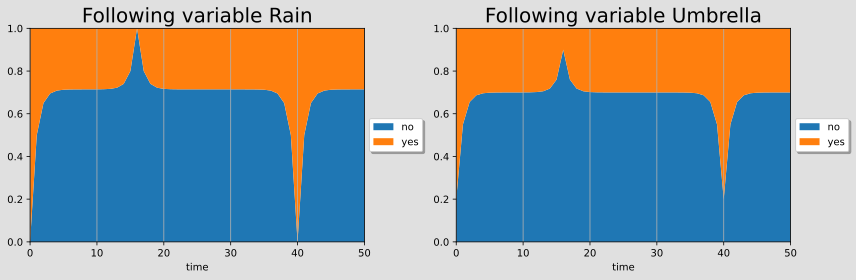

In wet season


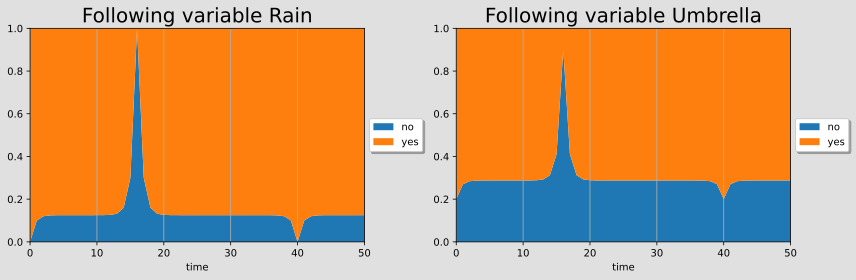

In [11]:
print("In dry season")
gnb.plotFollowKTBN(
  m,
  ["Rain", "Umbrella"],
  T=51,
  observations={"Rain[0]" : "yes","Rain[16]" : "no","Rain[40]" : "yes","Season":"dry"},
)
print("In wet season")  
gnb.plotFollowKTBN(
  m,
  ["Rain", "Umbrella"],
  T=51,
  observations={"Rain[0]" : "yes","Rain[16]" : "no","Rain[40]" : "yes","Season":"wet"},
)

## Persistence

A k-TBN is saved/loaded through `save`/`load` (or the free functions `saveKTBN`/`loadKTBN`), in a text (`.jgum`) or binary (`.bgum`) GUM format selected by the file extension. Bracket-encoded engine names are preserved literally through the round-trip, including nested brackets such as `"X[0][2]"` for a fast-syntax process named `X[2]` at slice 0.

In [12]:
import tempfile, os

path = os.path.join(tempfile.mkdtemp(), "weather.bgum")
m.save(path)
reloaded = ktbn.loadKTBN(path)
print(reloaded.k(), reloaded.sizeArcs())

2 5


## Randomly generating a k-TBN

`KTBNGenerator` draws a random template -- variables, a legal arc set, and (optionally) random CPTs -- mainly to build ground-truth models for learning experiments: sample trajectories, learn the structure back, and compare.

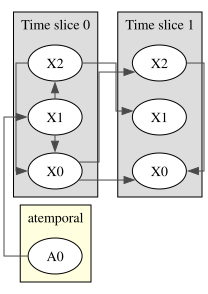

In [13]:
gum.initRandom(42)
gen = ktbn.KTBNGenerator(2, 3, 1)  # k=2, 3 temporal processes, 1 atemporal variable
gen.setDensity(0.4)
gm = gen.generate()
gm.generateCPTs()
gnb.showDot(gm.toDot())

## Sampling trajectories and learning a k-TBN back

Unlike a plain Bayesian network, a k-TBN describes a *process*: its database is a set of trajectories, one CSV file per trajectory, rather than a flat table of i.i.d. rows. `KTBNDatabaseGenerator` samples them by sliding the k-slice template forward in time.

In [14]:
dbgen = ktbn.KTBNDatabaseGenerator(gm)
outdir = tempfile.mkdtemp()
dbgen.drawSamples(5, 12, outdir, "traj")  # 5 trajectories of length 12

(-22.436296992179088,
 -31.222433641444802,
 -33.45845400225013,
 -31.319978846942398,
 -21.54004731681741)

`KTBNLearner` learns the order-`k` structure and parameters back from the trajectories. Domains are inferred from the first trajectory by default, which is unsafe for atemporal columns (constant within a trajectory, so only one label ever shows up in file 1): supplying a schema `BayesNet` with the full domains sidesteps that.

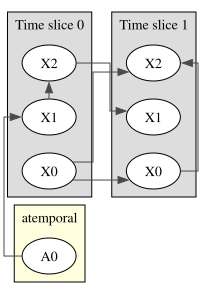

In [15]:
dbgen.drawSamples(200, 100, outdir, "traj")  # 200 trajectories of length 100

schema = gum.BayesNet()
for name in list(gm.temporalVarNames()) + list(gm.atemporalVarNames()):
  schema.add(gum.LabelizedVariable(name, "", ["0", "1"]))

learner = ktbn.KTBNLearner(outdir, "traj", 200, 2, schema, gm.atemporalVarNames())
learner.useScoreBIC().useGreedyHillClimbing()
learned = learner.learnKTBN()
gnb.showDot(learned.toDot())

When the order $k$ itself is unknown, `KTBNAdaptiveLearner` explores every candidate in `[2, kMax]`, learns one k-TBN per candidate, and keeps the one with the best cross-$k$ model-selection score (BIC by default).

In [16]:
adaptive = ktbn.KTBNAdaptiveLearner(outdir, "traj", 200, 5, schema, gm.atemporalVarNames())
adaptive.useScoreBIC().useGreedyHillClimbing()
best = adaptive.learnKTBN()
print("selected k :", adaptive.bestK())
print("score per candidate k :", adaptive.scorePerCandidateK())

selected k : 2
score per candidate k : ((2, -41461.31749561312), (3, -41509.43464003105), (4, -41542.5490839926), (5, -41589.266584422694))


## Multi-lag order and the summary graph

A k-TBN can depend on more than one lag at once: nothing forces the transition kernel to draw all its parents from the immediately preceding slice. This example builds a `k=4` model with three temporal processes `A`, `B`, `C`, where `A` depends on **two different lags** -- `A[0]` (lag 3) and `A[2]` (lag 1) -- combined so that `A` behaves as a 4-bit Fibonacci LFSR (linear-feedback shift register): `A[3]` is (almost) the XOR of `A[0]` and `A[2]`, a classic recipe for a long pseudo-random binary sequence. `B` and `C` relay that signal one lag at a time, so its effect propagates visibly through the whole network.

Fixed CPTs are used on purpose to get a reproducible, interesting dynamic rather than noise.

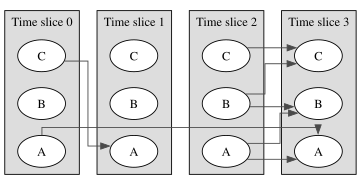

In [17]:
m = ktbn.KTBN(4)  # k=4

for name in ["A", "B", "C"]:
  m.addTemporal(gum.LabelizedVariable(name, "", ["0", "1"]))

# A[3] depends on two different lags: A[0] (lag 3) and A[2] (lag 1)
m.addArc("A", 0, "A", 3)
m.addArc("A", 2, "A", 3)

# B and C relay the signal one lag at a time
m.addArc("A", 2, "B", 3)
m.addArc("B", 2, "B", 3)
m.addArc("B", 2, "C", 3)
m.addArc("C", 2, "C", 3)

# Between t=1 and t=1 : a prior for C[0]-A[1]
m.addArc("C", 0, "A", 1)

gnb.show(m)

`A[3]` is fixed as a *noisy XOR* of its two lagged parents -- the LFSR feedback -- while `B` and `C` each mix their own lag-1 persistence with the upstream signal:

In [18]:
# A: initial slices are an unconstrained (uniform) seed for the LFSR
#for t in range(3):
#  m.fillCPT("A", t, {}, [0.5, 0.5])
m.generateCPTs()

# A[3] = noisy XOR(A[0], A[2]): the LFSR feedback
m.fillCPT("A", 3, {("A", 0): "0", ("A", 2): "0"}, [0.95, 0.05])
m.fillCPT("A", 3, {("A", 0): "0", ("A", 2): "1"}, [0.05, 0.95])
m.fillCPT("A", 3, {("A", 0): "1", ("A", 2): "0"}, [0.05, 0.95])
m.fillCPT("A", 3, {("A", 0): "1", ("A", 2): "1"}, [0.95, 0.05])

# B, C: uniform seed on slices 0..2, then a one-lag "relay" of the upstream signal
relay = {
  ("0", "0"): [0.9, 0.1],
  ("0", "1"): [0.3, 0.7],
  ("1", "0"): [0.1, 0.9],
  ("1", "1"): [0.7, 0.3],
}
for t in range(3):
  m.fillCPT("B", t, {}, [0.5, 0.5])
  m.fillCPT("C", t, {}, [0.5, 0.5])
for (upstream, own), dist in relay.items():
  m.fillCPT("B", 3, {("A", 2): upstream, ("B", 2): own}, dist)
  m.fillCPT("C", 3, {("B", 2): upstream, ("C", 2): own}, dist)

`summaryGraph()` collapses the template down to *only* the part that actually repeats when unrolling: the transition kernel, i.e. every arc whose head sits in the last time slice (`k-1 = 3` here). It draws one node per process and labels each arc with its lag, so the two different lags feeding `A` show up as two distinct self-loops:

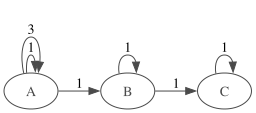

In [19]:
gnb.showDot(m.summaryGraph())

Fixing part of the LFSR's seed and letting `KTBNInference` run past `k=4` shows the kernel replicating -- and the delayed relay through `B` and `C`:

In [20]:
kie = ktbn.KTBNInference(m)
kie.addObservation("A", 0, "1")
kie.addObservation("A", 2, "0")
kie.makeInference(10)  # horizon well beyond k=4: the kernel keeps replicating

for name in ["A", "B", "C"]:
  series = kie.posteriors(name)
  print(f"P({name}[t]=1 | A[0]=1, A[2]=0), t=0..{len(series) - 1} :")
  print([round(p.tolist()[1], 3) for p in series])

P(A[t]=1 | A[0]=1, A[2]=0), t=0..9 :
[1.0, 0.696, 0.0, 0.95, 0.341, 0.357, 0.643, 0.828, 0.629, 0.172]
P(B[t]=1 | A[0]=1, A[2]=0), t=0..9 :
[0.5, 0.5, 0.5, 0.4, 0.644, 0.502, 0.464, 0.579, 0.52, 0.542]
P(C[t]=1 | A[0]=1, A[2]=0), t=0..9 :
[0.5, 0.5, 0.5, 0.5, 0.444, 0.567, 0.488, 0.483, 0.536, 0.526]


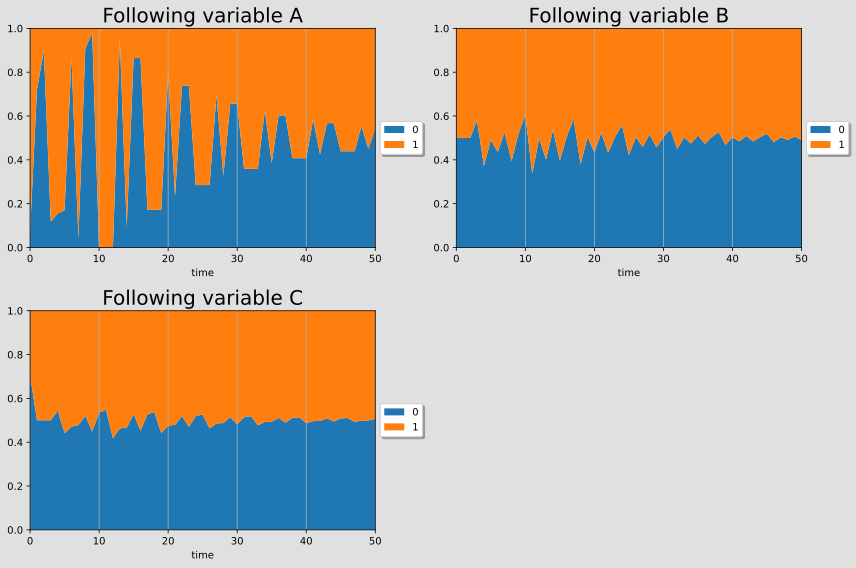

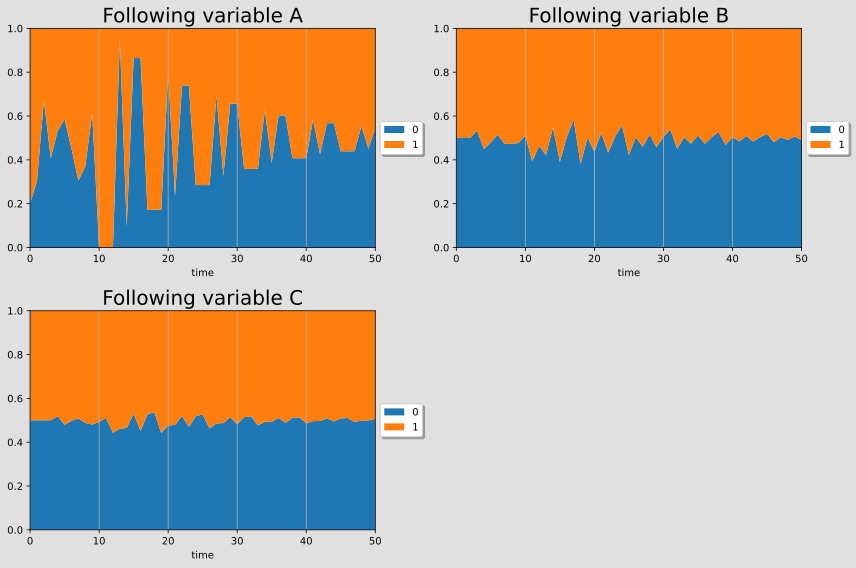

In [21]:
gnb.plotFollowKTBN(
  m,
  ["A", "B", 'C'],
  T=51,
  observations={"A[10]":1,"A[11]":1,"A[12]":1}
)
gnb.plotFollowKTBN(
  m,
  ["A", "B", 'C'],
  T=51,
  interventions={"A[10]":1,"A[11]":1,"A[12]":1}
)

`KTBNDatabaseGenerator` draws trajectories from this fixed-CPT model, and `KTBNLearner` tries to recover a k-TBN back from them when `k=4` is given (the true order). Structure learning from a finite sample does not always land on the exact causal direction, though: greedy hill climbing can settle for a statistically-equivalent but non-causal proxy -- here, attributing `A`'s dependency to `B` (which is itself driven by `A` with a lag, and thus correlated with it) instead of to `A` directly. Compare the arcs and lags in `learned.summaryGraph()` below with the original one above:

In [22]:
gum.initRandom(42)  # reproducible sampling

dbgen = ktbn.KTBNDatabaseGenerator(m)
outdir = tempfile.mkdtemp()
dbgen.drawSamples(300, 60, outdir, "abc")  # 300 trajectories of length 60

schema = gum.BayesNet()
for name in list(m.temporalVarNames()) + list(m.atemporalVarNames()):
  schema.add(gum.LabelizedVariable(name, "", ["0", "1"]))

learner = ktbn.KTBNLearner(outdir, "abc", 300, 4, schema, m.atemporalVarNames())
learner.useScoreBIC().useGreedyHillClimbing()
learned = learner.learnKTBN()
gnb.sideBySide(gnb.getDot(learned.summaryGraph()),gnb.getDot(learned.toDot()))

KTBN <!-- A --> A A <!-- B --> B B <!-- A->B --> A->B 1 <!-- B->A --> B->A 1 <!-- B->A --> B->A 3 <!-- B->B --> B->B 1 <!-- C --> C C <!-- B->C --> B->C 1 <!-- C->C --> C->C 1


When `k` itself is unknown, `KTBNAdaptiveLearner` searches `[2, kMax]` and keeps the best-scoring order. Giving the search one extra slice of room removes the ambiguity above: a k=5 window lets the algorithm tell `A`'s own dual-lag dependency apart from its correlated echo in `B`, which shows up as a markedly better score for that candidate -- exactly the kind of trade-off `scorePerCandidateK()` is meant to expose:

In [23]:
adaptive = ktbn.KTBNAdaptiveLearner(outdir, "abc", 300, 6, schema, m.atemporalVarNames())
adaptive.useScoreBIC().useGreedyHillClimbing()
best = adaptive.learnKTBN()
print("selected k :", adaptive.bestK())
print("score per candidate k :", adaptive.scorePerCandidateK())
gnb.sideBySide(gnb.getDot(best.summaryGraph()),gnb.getDot(best.toDot()))

selected k : 5
score per candidate k : ((2, -43007.12075785022), (3, -42295.32813979397), (4, -42472.6698805135), (5, -30493.022351257227), (6, -35286.75600905307))


KTBN <!-- A --> A A <!-- A->A --> A->A 1 <!-- A->A --> A->A 3 <!-- B --> B B <!-- A->B --> A->B 1 <!-- B->B --> B->B 1 <!-- C --> C C <!-- B->C --> B->C 1 <!-- C->C --> C->C 1
